In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path



startup
Not on GPU


In [2]:
use_gpu=False
sum_kwargs = {
            "pad_output": True}
waveform_derivative = StableEMRIDerivative(waveform_class=SuperKludgeWaveform,sum_kwargs=sum_kwargs,\
                                           mode_selector_kwargs=dict(mode_selection_threshold=1e-5), 
                                          inspiral_kwargs=dict(err=1e-11, max_iter=10000))

In [13]:
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.01
xI0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 0.5
chi2 = 0.6

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=10.0
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,chi2]
param_names = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2"]

In [15]:
parameters = {}
for i in range(len(param_names)):
    parameters[param_names[i]] = pars_list[i]

param_to_vary = 'm1'

delta = 1e-5  #finite difference delta for the chosen paramete
order = 4 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative

der = waveform_derivative(T = T, dt = dt, 
                    parameters = parameters, 
                    param_to_vary = param_to_vary,
                    delta = delta,
                    order = order,
                    kind = kind,
                    )

if use_gpu:
    der = der.get()


0


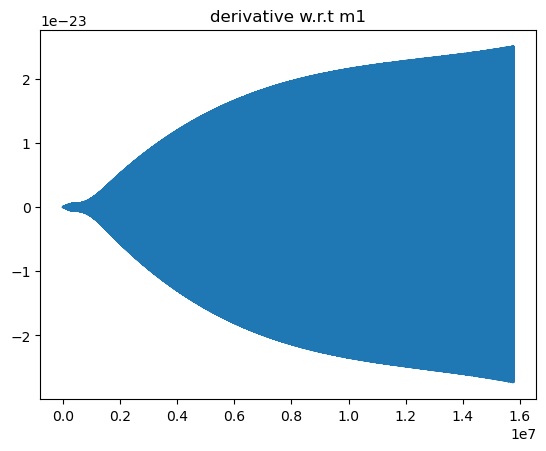

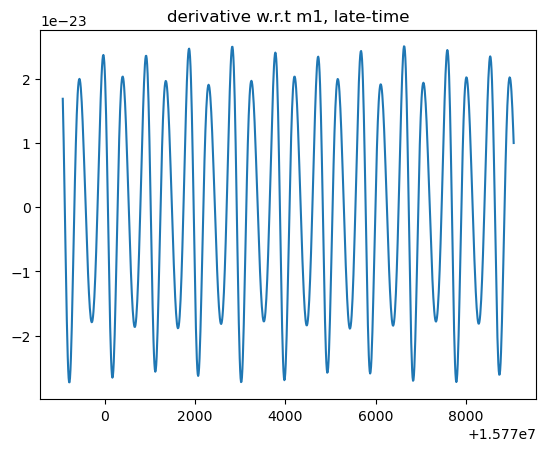

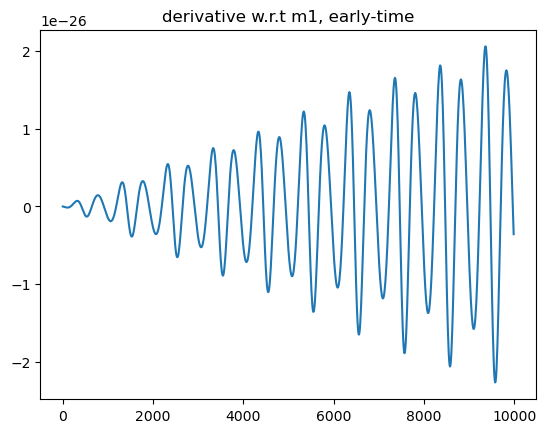

In [16]:
Npad = waveform_derivative.cache['Npad']

print(Npad)

if Npad == 0:
    Npad = 1
    
times = np.arange(len(der))*dt
plt.plot(times, der.real)
plt.title(f"derivative w.r.t {param_to_vary}")
plt.show()

times = np.arange(len(der))*dt
plt.plot(times[-Npad - 1000: - Npad], der.real[-Npad - 1000: -Npad])
plt.title(f"derivative w.r.t {param_to_vary}, late-time")
plt.show()

plt.plot(times[:1000], der.real[:1000])
plt.title(f"derivative w.r.t {param_to_vary}, early-time")
plt.show()